# **Previsão de Churn - Cartão de Crédito**

Neste projeto, o objetivo é construir um modelo de **Machine Learning** capaz de prever a probabilidade de um cliente cancelar (entrar em *churn*) o serviço de cartão de crédito de um banco. Trata-se de um problema de **Classificação Supervisionada**, onde a variável alvo (*target*) é `1` se o cliente cancelou e `0` caso contrário.

O desenvolvimento deste modelo segue as etapas fundamentais do framework **CRISP-DM**:

1. **Entendimento do Negócio:** Definição do problema e dos objetivos.
2. **Compreensão dos Dados:** Coleta e visão geral das variáveis disponíveis.
3. **Preparação dos Dados:** Divisão em conjuntos de treino e teste, limpeza e pré-processamento.
4. **Análise Exploratória de Dados (EDA):** Extração de *insights* e entendimento do comportamento do cliente.
5. **Engenharia de Features:** Criação de novas variáveis para melhorar o poder preditivo.
6. **Modelagem:** Treinamento, comparação, seleção de *features* e otimização de hiperparâmetros.
7. **Avaliação:** Teste do modelo e interpretação dos resultados.
8. **Deploy:** Implantação do modelo em ambiente de produção.

> **Foco deste Notebook:** Realizar a **Análise Exploratória de Dados (EDA)** (etapas 1 a 4). O principal objetivo é descobrir *insights* valiosos sobre os padrões dos clientes que cancelam (*churners*) antes mesmo da modelagem. Isso permitirá ao banco agir estrategicamente com base em perfis e tendências identificadas.


## **1. Problema de Negócio**

Um gerente de banco identificou um aumento preocupante na taxa de cancelamento (*churn*) dos serviços de cartão de crédito. O objetivo é prever a probabilidade de um cliente cancelar o serviço, permitindo que a equipe de retenção aja de forma **proativa** para oferecer alternativas e reverter a decisão antes do cancelamento efetivo.

### Contexto e KPIs Essenciais

O sucesso financeiro de uma operação de cartão de crédito depende do equilíbrio entre três Indicadores Chave de Desempenho (KPIs):

1. **Custo de Aquisição de Clientes (CAC):** Mede as despesas associadas à atração de cada novo cliente (marketing, vendas, operacional). Um CAC menor reflete maior eficiência.
2. **Valor do Ciclo de Vida do Cliente (CLV - *Customer Lifetime Value*):** Estima a receita total que o banco gerará com um cliente ao longo do relacionamento. Para garantir rentabilidade, o CLV deve ser **maior** que o CAC.
3. **Taxa de Churn (Cancelamento):** Percentual de clientes que deixaram o serviço em um determinado período.

> **Regra de Ouro da Rentabilidade:** Minimizar o **CAC** e a **Taxa de Churn**, enquanto se maximiza o **CLV**.

### Objetivos do Projeto

- **Identificar os fatores** mais fortemente associados ao *churn* de clientes.
- **Construir um modelo preditivo** que calcule a probabilidade de cancelamento para cada cliente.
- **Desenhar planos de ação** orientados por dados para reduzir a evasão na carteira.

### Por que prever Probabilidades (Score) em vez de Classificação Binária?

Em vez de fornecer um veredito engessado ("Vai cancelar" `[1]` ou "Não vai cancelar" `[0]`), o modelo gerará um *score* de probabilidade (ex: *85% de chance de cancelamento*). Isso traz vantagens estratégicas:

* **Ação Direcionada:** O banco pode alocar orçamento focando primeiro nos clientes de **altíssimo risco**, otimizando o ROI das campanhas.
* **Estratégias Customizadas:** Clientes com risco moderado podem receber incentivos mais leves (ex: isenção de anuidade), enquanto os de risco crítico podem exigir contato direto do gerente.

### Benefícios Esperados

* **Redução de Custos:** Reter um cliente ativo é consideravelmente mais barato do que adquirir um novo.
* **Aumento da Retenção:** Identificação precoce de insatisfação ou desengajamento.
* **Proteção de Receita:** Mitigação da perda de faturamento gerado por anuidades e tarifas.
* **Melhoria da Experiência (CX):** Intervenções proativas demonstram cuidado e aumentam o engajamento do cliente.


### **Importando as bibliotecas**

In [2]:
# Data manipulation and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

# Split the data.
from sklearn.model_selection import train_test_split

# Utils
from src.utils.visualization import analysis_plots, check_outliers

# Filter warnings.
import warnings
warnings.filterwarnings('ignore')

## **2. Entendendo os Dados**

* O conjunto de dados original está disponível no **Kaggle**: [Credit Card Customers](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers?sort=votes) (Fonte original: [Analyttica Leaps](https://leaps.analyttica.com/home)).
* Ele contém informações detalhadas de clientes, incluindo aspectos **demográficos**, **financeiros** e de uso do **produto**.
* O *dataset* já está rotulado na variável `Attrition_Flag`: clientes que cancelaram (*churners*) são representados por `1`, e clientes retidos por `0`.

> ⚠️ **Nota sobre limpeza inicial:** As duas últimas colunas do dataset parecem ser saídas de um modelo *Naive Bayes* previamente executado pelo autor do dataset original. Como não temos o contexto exato da sua criação, elas serão removidas para evitar vazamento de dados (*data leakage*).


In [3]:
data_path = "../data/interim/BankChurners.csv"
df = pd.read_csv(data_path)

# DropFeatures
df.drop(columns=['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1'], inplace=True)

In [4]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


### Dicionário de Dados

Abaixo estão os detalhes de cada variável presente no conjunto de dados:

| Variável | Descrição | Tipo de Dado |
| :--- | :--- | :--- |
| **CLIENTNUM** | Identificador único do cliente. | Categórica Nominal |
| **Attrition_Flag** | Variável alvo (*target*). Indica se a conta foi fechada (`1`) ou não (`0`). | Categórica Binária |
| **Customer_Age** | Idade do cliente em anos. | Numérica Discreta |
| **Gender** | Gênero do cliente (`M` = Masculino, `F` = Feminino). | Categórica Nominal |
| **Dependent_count** | Número de dependentes. | Numérica Discreta |
| **Education_Level** | Nível de escolaridade (ex: Ensino Médio, Graduação, etc.). | Categórica Ordinal |
| **Marital_Status** | Estado civil (Casado, Solteiro, Divorciado, Desconhecido). | Categórica Nominal |
| **Income_Category** | Faixa de renda anual do cliente. | Categórica Ordinal |
| **Card_Category** | Tipo do cartão de crédito (Blue, Silver, Gold, Platinum). | Categórica Ordinal |
| **Months_on_book** | Tempo de relacionamento com o banco (em meses). | Numérica Discreta |
| **Total_Relationship_Count** | Número total de produtos que o cliente possui no banco. | Numérica Discreta |
| **Months_Inactive_12_mon** | Quantidade de meses inativos nos últimos 12 meses. | Numérica Discreta |
| **Contacts_Count_12_mon** | Número de contatos do cliente com o banco nos últimos 12 meses. | Numérica Discreta |
| **Credit_Limit** | Limite de crédito total do cartão. | Numérica Contínua |
| **Total_Revolving_Bal** | Saldo rotativo total no cartão de crédito. | Numérica Discreta |
| **Avg_Open_To_Buy** | Linha de crédito aberta disponível para compra (média dos últimos 12 meses). | Numérica Contínua |
| **Total_Amt_Chng_Q4_Q1** | Mudança no valor das transações (Q4 vs Q1). | Numérica Contínua |
| **Total_Trans_Amt** | Valor total das transações realizadas nos últimos 12 meses. | Numérica Discreta |
| **Total_Trans_Ct** | Contagem total de transações realizadas nos últimos 12 meses. | Numérica Discreta |
| **Total_Ct_Chng_Q4_Q1** | Mudança na contagem de transações (Q4 vs Q1). | Numérica Contínua |
| **Avg_Utilization_Ratio** | Taxa média de utilização do limite de crédito do cartão. | Numérica Contínua |


Observando as informações gerais do conjunto de dados.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  str    
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  str    
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  str    
 6   Marital_Status            10127 non-null  str    
 7   Income_Category           10127 non-null  str    
 8   Card_Category             10127 non-null  str    
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_Revolving_B

In [6]:
print(f'O dataset tem {df.shape[0]} linhas e {df.shape[1]} colunas.')

O dataset tem 10127 linhas e 21 colunas.


Observando algumas estatísticas descritivas.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,708082083.0,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,26.0,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.0,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,13.0,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1438.3,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.0,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.0,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


### Insights Iniciais da Estatística Descritiva

1. **Perfil Etário:** A idade média é de ~46 anos, com 50% dos clientes concentrados entre 41 e 52 anos. O público alvo possui um perfil mais maduro.
2. **Engajamento com Produtos:** Em média, os clientes possuem cerca de 4 produtos diferentes com o banco.
3. **Inatividade Preocupante:** 75% dos clientes ficaram pelo menos 2 meses inativos no último ano. **Ação:** O banco precisa de estratégias de reengajamento para estimular o uso do cartão.
4. **Contatos Frequentes:** 75% dos clientes entraram em contato com o atendimento pelo menos 2 vezes no último ano. Isso pode ser um forte indicativo de **fricção ou insatisfação** com o serviço.
5. **Distribuição de Limite de Crédito:** O limite médio é de $8.632, mas a distribuição é assimétrica à direita (a média é superior à mediana), com limites variando de $1.438 a incríveis $34.516.
6. **Baixa Utilização do Cartão:** A taxa média de utilização é de apenas ~28%. Metade dos clientes utiliza até 17,6% do limite. **Ação:** Desenvolver campanhas de incentivo ao uso para aumentar a rentabilidade.
7. **Volume de Transações:** A média é de ~65 transações por ano (cerca de 5,4 por mês), um volume considerado muito baixo para um cartão de crédito de uso contínuo.
8. **Qualidade dos Dados:** Analisando os valores mínimos e máximos, não identificamos *outliers* absurdos ou valores impossíveis nas variáveis numéricas iniciais.


Observando valores ausentes e duplicados.

In [8]:
df.isna().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

Não há valores ausentes ou duplicados.

- Vou descartar a variável CLIENTNUM porque ela tem um valor único para cada registro, não sendo útil para a análise.
- Vou renomear as colunas em um formato padrão para facilitar a manipulação. Além disso, attrition_flag será renomeada para churn_flag para fins de interpretação.
- Vou expressar as variáveis Gender e Attrition_Flag como binárias. Isso facilitará a análise, por exemplo, ao olhar para valores percentuais.

In [10]:
df.drop(columns=['CLIENTNUM'], inplace=True)

In [11]:
df.columns = [x.lower() for x in df.columns]

In [12]:
df['gender'] = df['gender'].map({'M': 1, 'F': 0})
df['attrition_flag'] = df['attrition_flag'].map({'Attrited Customer': 1, 'Existing Customer': 0})

In [13]:
df.rename(columns={'attrition_flag': 'churn_flag'}, inplace=True)

## **3. Divisão dos Dados (Treino e Teste)**

Antes de iniciar qualquer análise profunda, é fundamental separar os dados em conjuntos de **Treino** e **Teste**.

* **Evitando Data Leakage:** A Análise Exploratória (EDA) deve ser feita **exclusivamente** no conjunto de treino. Isso garante que não "vazaremos" informações do teste para nossas decisões de modelagem, simulando um cenário real.
* **Estratificação:** O parâmetro `stratify=y` será utilizado para manter a proporção exata de *churners* e clientes retidos em ambos os conjuntos, algo crucial para *datasets* desbalanceados.


In [14]:
X = df.drop(columns=['churn_flag'])
y = df['churn_flag'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [15]:
print(f'Formato do dataset de preditores de treino: {X_train.shape}.')
print(f'Formato do dataset do alvo de treino: {y_train.shape}.')
print(f'Formato do dataset de preditores de teste: {X_test.shape}.')
print(f'Formato do dataset do alvo de teste: {y_test.shape}.')

Formato do dataset de preditores de treino: (8101, 19).
Formato do dataset do alvo de treino: (8101,).
Formato do dataset de preditores de teste: (2026, 19).
Formato do dataset do alvo de teste: (2026,).


In [16]:
print(f'Proporção do alvo no treino: ')
print(f'{y_train.value_counts(normalize=True)}')
print(f'\nProporção do alvo no teste: ')
print(f'{y_test.value_counts(normalize=True)}')

Proporção do alvo no treino: 
churn_flag
0    0.839279
1    0.160721
Name: proportion, dtype: float64

Proporção do alvo no teste: 
churn_flag
0    0.839585
1    0.160415
Name: proportion, dtype: float64


As proporções das classes alvo (target) foram preservadas.

## **4. Análise Exploratória de Dados (EDA)**

Nesta etapa, focaremos no **conjunto de treinamento** para investigar o comportamento das *features*, identificar padrões, correlações e extrair insights estratégicos relacionados à variável alvo (`churn_flag`).

> **Abordagem:** Conduziremos análises Univariadas, Bivariadas e Multivariadas. Para facilitar a visualização de correlações e o uso do parâmetro `hue` no Seaborn, mesclaremos temporariamente as *features* (`X_train`) e o alvo (`y_train`) em um único *DataFrame*.


In [17]:
train = pd.concat([X_train, y_train], axis=1)
train.head()

,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,churn_flag
2856,36,0,0,Unknown,Married,Less than $40K,Blue,24,4,3,2,2570.0,2230,340.0,0.686,1755,42,0.448,0.868,0
6515,44,1,3,High School,Single,$60K - $80K,Silver,36,5,2,3,25276.0,0,25276.0,0.849,2282,38,0.583,0.000,1
7141,46,1,2,High School,Married,$80K - $120K,Blue,30,6,3,1,11670.0,915,10755.0,0.892,4277,89,0.854,0.078,0
632,36,0,2,Graduate,Married,Less than $40K,Blue,24,3,1,3,3124.0,1593,1531.0,0.869,1652,41,0.367,0.510,0
3496,50,1,1,Graduate,Single,$120K +,Blue,40,4,2,3,34516.0,1185,33331.0,0.725,3874,72,0.714,0.034,0


Vou criar listas separadas para features categóricas, numéricas e alvo para analisar separadamente.

In [18]:
numerical_features = X_train.select_dtypes('number').columns.tolist()
categorical_features = X_train.select_dtypes('object').columns.tolist()
target = 'churn_flag'

print(f'Existem {len(numerical_features)} features numéricas. Elas são: ')
print(numerical_features)
print(f'\nExistem {len(categorical_features)} features categóricas. Elas são: ')
print(categorical_features)
print(f'\nA feature alvo é: {target}.')

Existem 15 features numéricas. Elas são: 
['customer_age', 'gender', 'dependent_count', 'months_on_book', 'total_relationship_count', 'months_inactive_12_mon', 'contacts_count_12_mon', 'credit_limit', 'total_revolving_bal', 'avg_open_to_buy', 'total_amt_chng_q4_q1', 'total_trans_amt', 'total_trans_ct', 'total_ct_chng_q4_q1', 'avg_utilization_ratio']

Existem 4 features categóricas. Elas são: 
['education_level', 'marital_status', 'income_category', 'card_category']

A feature alvo é: churn_flag.


Vou analisar os valores únicos das features categóricas. A cardinalidade é um fator importante na escolha da técnica de codificação.

In [19]:
for feature in categorical_features:
    print(feature)
    print('-'*40)
    print(f'Existem {train[feature].nunique()} valores únicos. Eles são: ')
    print(train[feature].value_counts(normalize=True))
    print()

education_level
----------------------------------------
Existem 7 valores únicos. Eles são: 
education_level
Graduate         0.306382
High School      0.203679
Unknown          0.148994
Uneducated       0.146031
College          0.098259
Post-Graduate    0.052710
Doctorate        0.043945
Name: proportion, dtype: float64

marital_status
----------------------------------------
Existem 4 valores únicos. Eles são: 
marital_status
Married     0.463523
Single      0.387853
Unknown     0.074682
Divorced    0.073941
Name: proportion, dtype: float64

income_category
----------------------------------------
Existem 6 valores únicos. Eles são: 
income_category
Less than $40K    0.349586
$40K - $60K       0.178990
$80K - $120K      0.149241
$60K - $80K       0.140230
Unknown           0.109369
$120K +           0.072584
Name: proportion, dtype: float64

card_category
----------------------------------------
Existem 4 valores únicos. Eles são: 
card_category
Blue        0.933095
Silver      0.0

- **education_level**, **income_category** e **card_category** apresentam relações ordinais. Portanto, `OrdinalEncoder` pode ser uma boa escolha para transformação.
- Com exceção da *card_category*, todos os atributos categóricos possuem a categoria `Unknown` (desconhecido). Investigaremos a distribuição de *churn* dentro desta categoria. Se a categoria `Unknown` ajudar a discriminar *churners*, será mantida como uma categoria separada, pois imputar valores pode introduzir viés desnecessário.


### Análise Univariada

Nesta etapa, focaremos em avaliar individualmente cada variável. Nosso objetivo é compreender a distribuição e os valores típicos de cada *feature* demográfica e comportamental para os clientes do banco.


### Distribuição do Alvo (Target)

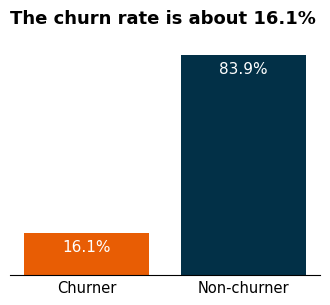

In [20]:
# Group the data by churn flag.
churn_grp = train.groupby(['churn_flag'])[['churn_flag']].count().rename(columns={'churn_flag': 'count'}).reset_index()
churn_grp['pct'] = (churn_grp['count'] / churn_grp['count'].sum()) * 100
churn_grp = churn_grp.sort_values(by=['pct'])

# Define the plot.
fig, ax = plt.subplots(figsize=(4, 3))
        
# Plot the barplot.
bars = ax.bar(x=churn_grp['churn_flag'], height=churn_grp['pct'], color=['#e85d04', '#023047'])
        
# Customize the plot.
ax.set_title('The churn rate is about 16.1%', fontweight='bold', fontsize=13, pad=15, loc='left')
ax.set_xlabel('')
ax.set_xticks(ticks=range(2), labels=['Non-churner', 'Churner'], fontsize=10.5)
ax.tick_params(axis=u'both', which=u'both',length=0)
ax.invert_xaxis()
        
ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(False)

for bar in bars:
    height = bar.get_height()
    ax.annotate('{:.1f}%'.format(height), 
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, -10),  
                textcoords="offset points",
                ha='center', va='center',
                fontsize=11, color='white')

### Distribuição da Variável Alvo (Churn)

O gráfico acima revela um cenário crítico de desbalanceamento de classes: **Apenas 16,1% dos clientes são churners.**

Para construir um modelo preditivo robusto diante desse desbalanceamento, adotaremos as seguintes estratégias de modelagem:
* **Validação Cruzada Estratificada:** Utilizar *Stratified K-Fold* para manter a proporção real em todos os *folds*.
* **Pesos de Classe (Class Weights):** Atribuir pesos maiores à classe minoritária (churners) durante o treinamento, penalizando fortemente os falsos negativos (não identificar um cliente que vai cancelar).
* **Métricas Apropriadas:** Evitar a Acurácia simples e focar no **ROC-AUC** e na curva **Precision-Recall**, já que nosso objetivo primário é gerar um excelente *Score* de probabilidade.


### Distribuições das features numéricas
Vou analisar as distribuições das features numéricas abaixo para ver se há distribuições distorcidas e quais são os valores mais comuns.

In [21]:
numplots_features = ['customer_age', 
                     'months_on_book', 
                     'credit_limit', 
                     'total_revolving_bal', 
                     'avg_open_to_buy', 
                     'total_amt_chng_q4_q1', 
                     'total_trans_amt', 
                     'total_trans_ct', 
                     'total_ct_chng_q4_q1', 
                     'avg_utilization_ratio',
                     'total_relationship_count']

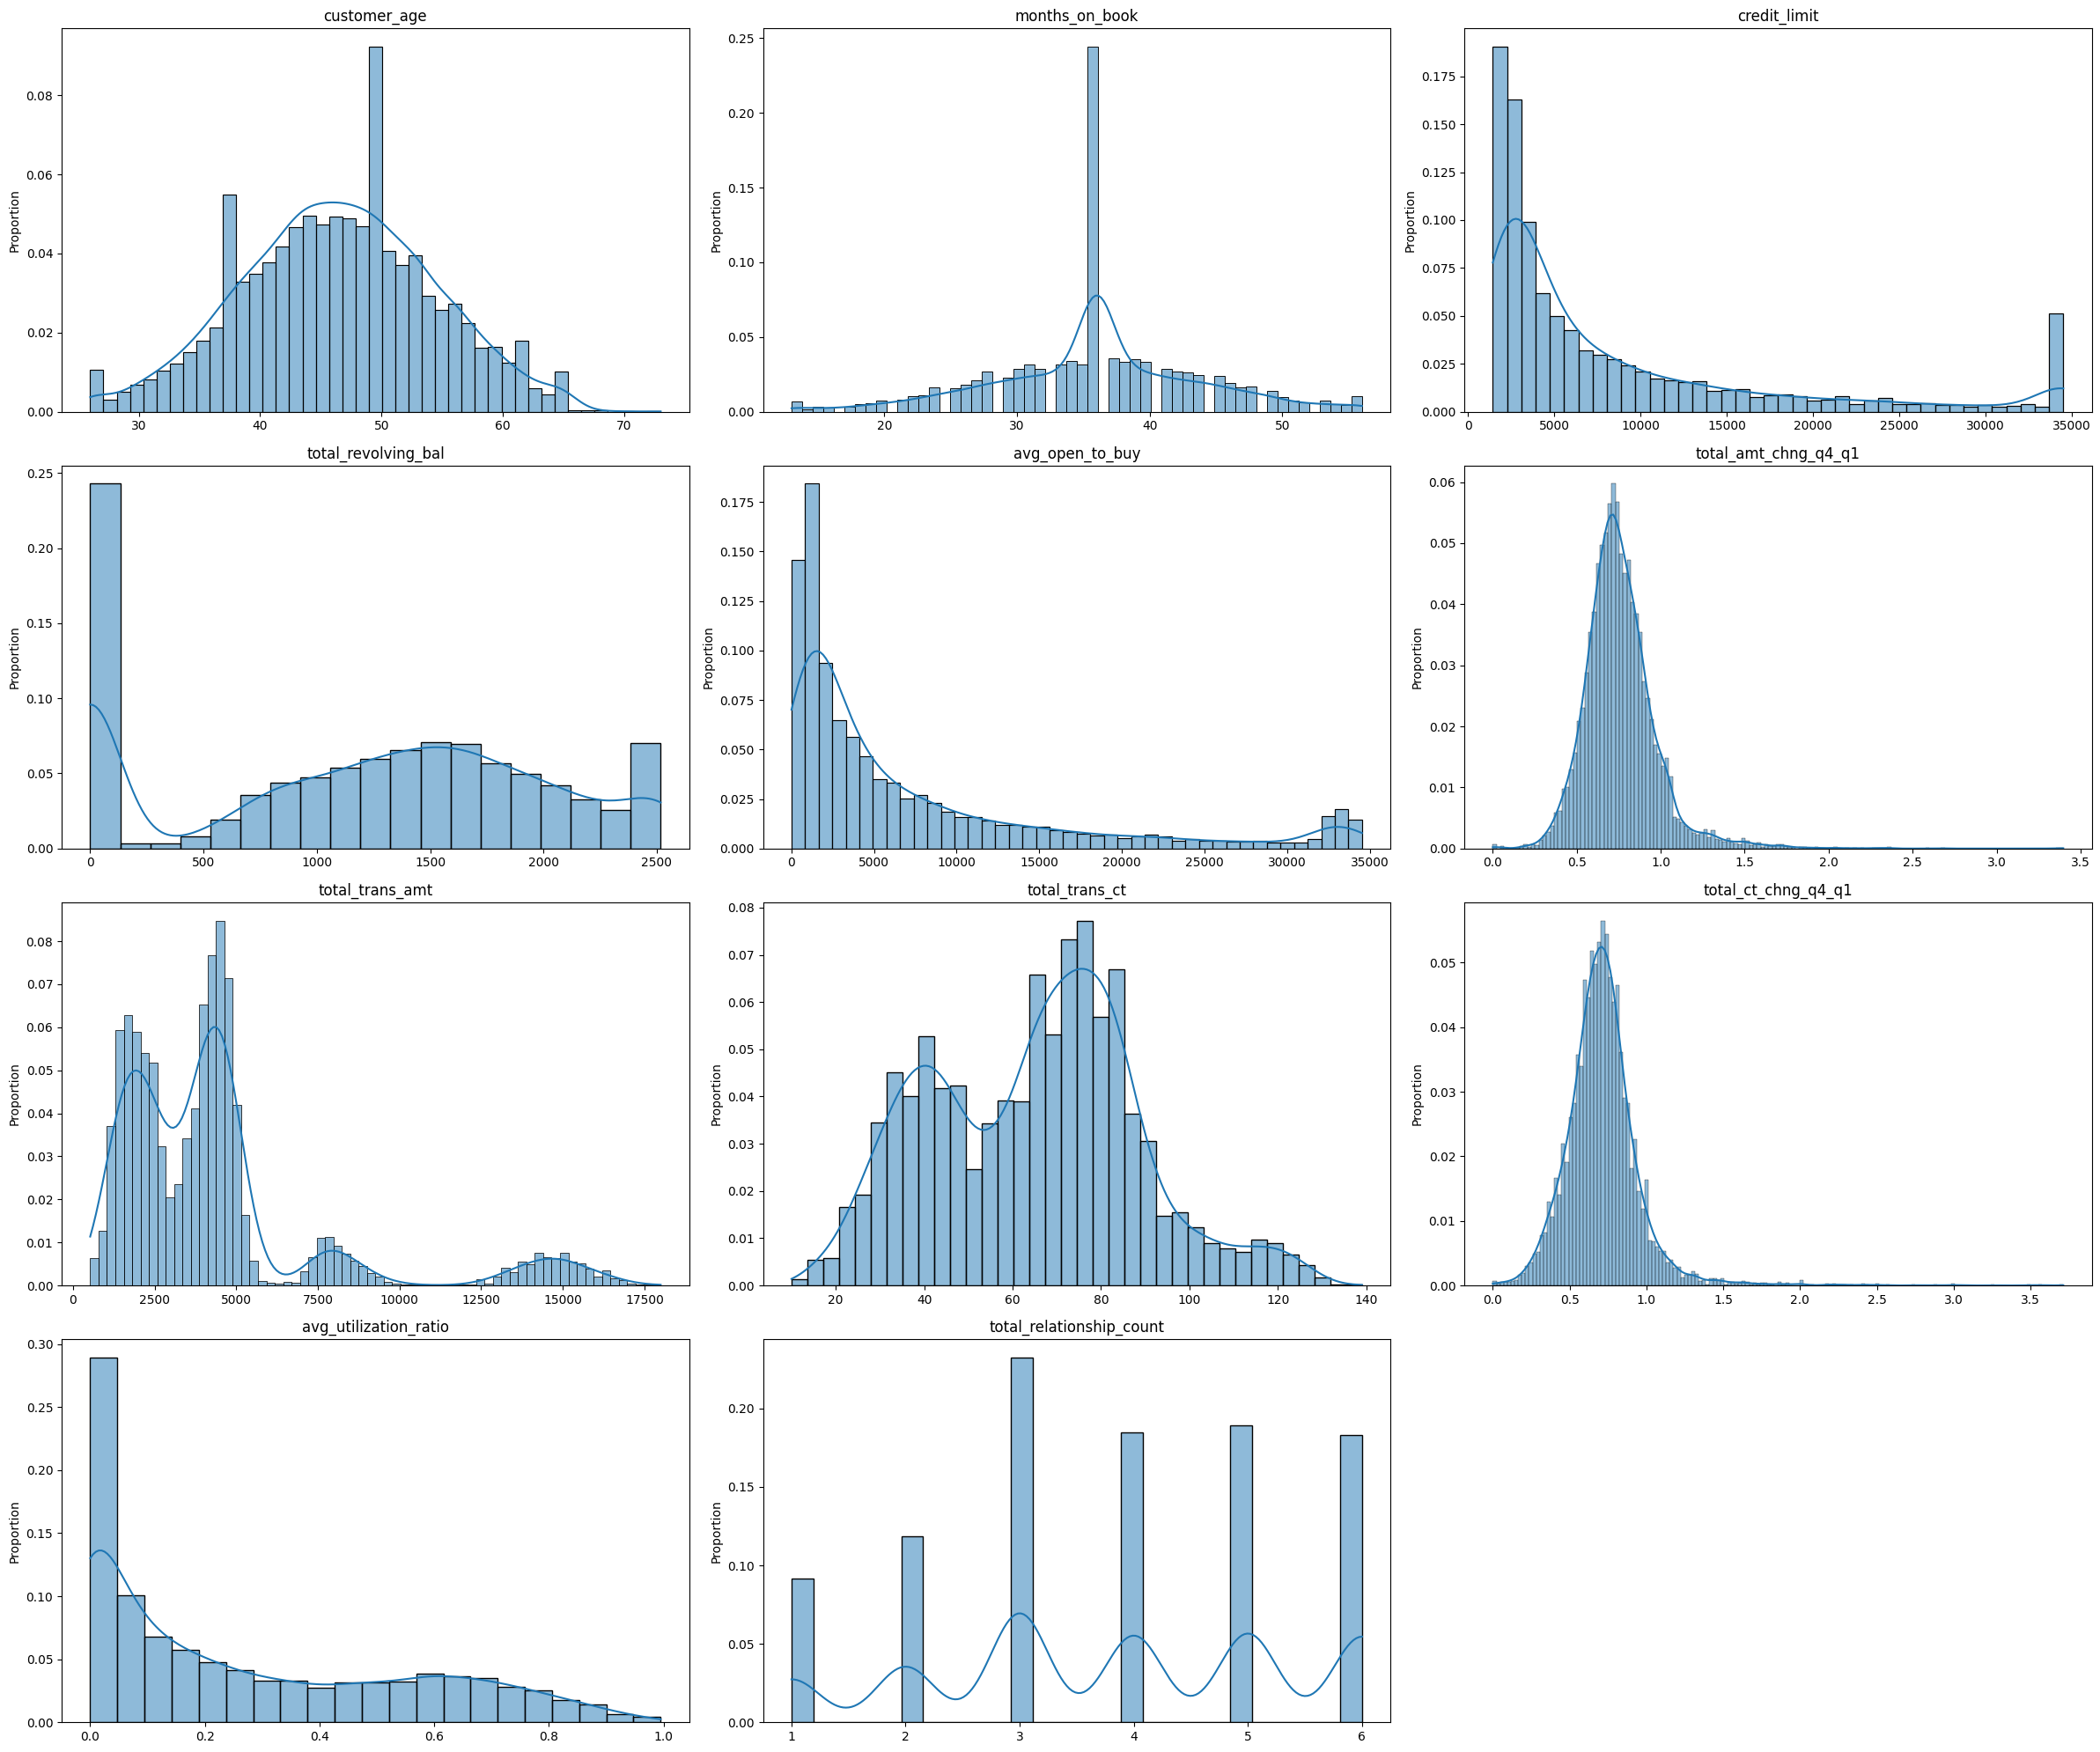

In [22]:
analysis_plots(data=train, features=numplots_features, kde=True, figsize=(24, 20))

Insights:
- A maioria dos clientes tem entre 40 e 50 anos.
- Grande parte dos clientes passou 36 meses consumindo os serviços do banco.
- O limite de crédito é enviesado à direita. A maioria tem limites baixos, enquanto poucos têm limites muito altos (cerca de 5% chega a 35.000). avg_open_to_buy e avg_utilization_ratio também têm viés positivo.
- O banco deve estar alerta à distribuição da taxa de utilização média. Enviesada à direita significa que a maioria tem baixa utilização. Cerca de 25% apresentam taxa de utilização zero.
- Grande parte (cerca de 25%) também possui saldo rotativo total zero, o que pode indicar probabilidade significativa de churn. Essas variáveis podem estar correlacionadas.
- A contagem e o valor total de transações parecem ter dois picos. Deve haver uma distinção nessas distribuições em relação ao churn, que investigarei.
- Cerca de 80% dos clientes possuíam pelo menos 3 produtos do banco.

### Outliers
Vou olhar os outliers para ver se representam informações inconsistentes como erros de medição. Depois decidirei se os tratarei ou não. Além disso, plotarei boxplots para visualização.

In [23]:
outlier_indexes, outlier_counts, total_outliers = check_outliers(data=train, features=numplots_features)

Existem 3344 outliers no dataset.

Número (porcentagem) de outliers por feature: 

customer_age: 2 (0.02)%
months_on_book: 450 (5.55)%
credit_limit: 784 (9.68)%
total_revolving_bal: 0 (0.0)%
avg_open_to_buy: 775 (9.57)%
total_amt_chng_q4_q1: 311 (3.84)%
total_trans_amt: 704 (8.69)%
total_trans_ct: 1 (0.01)%
total_ct_chng_q4_q1: 317 (3.91)%
avg_utilization_ratio: 0 (0.0)%
total_relationship_count: 0 (0.0)%


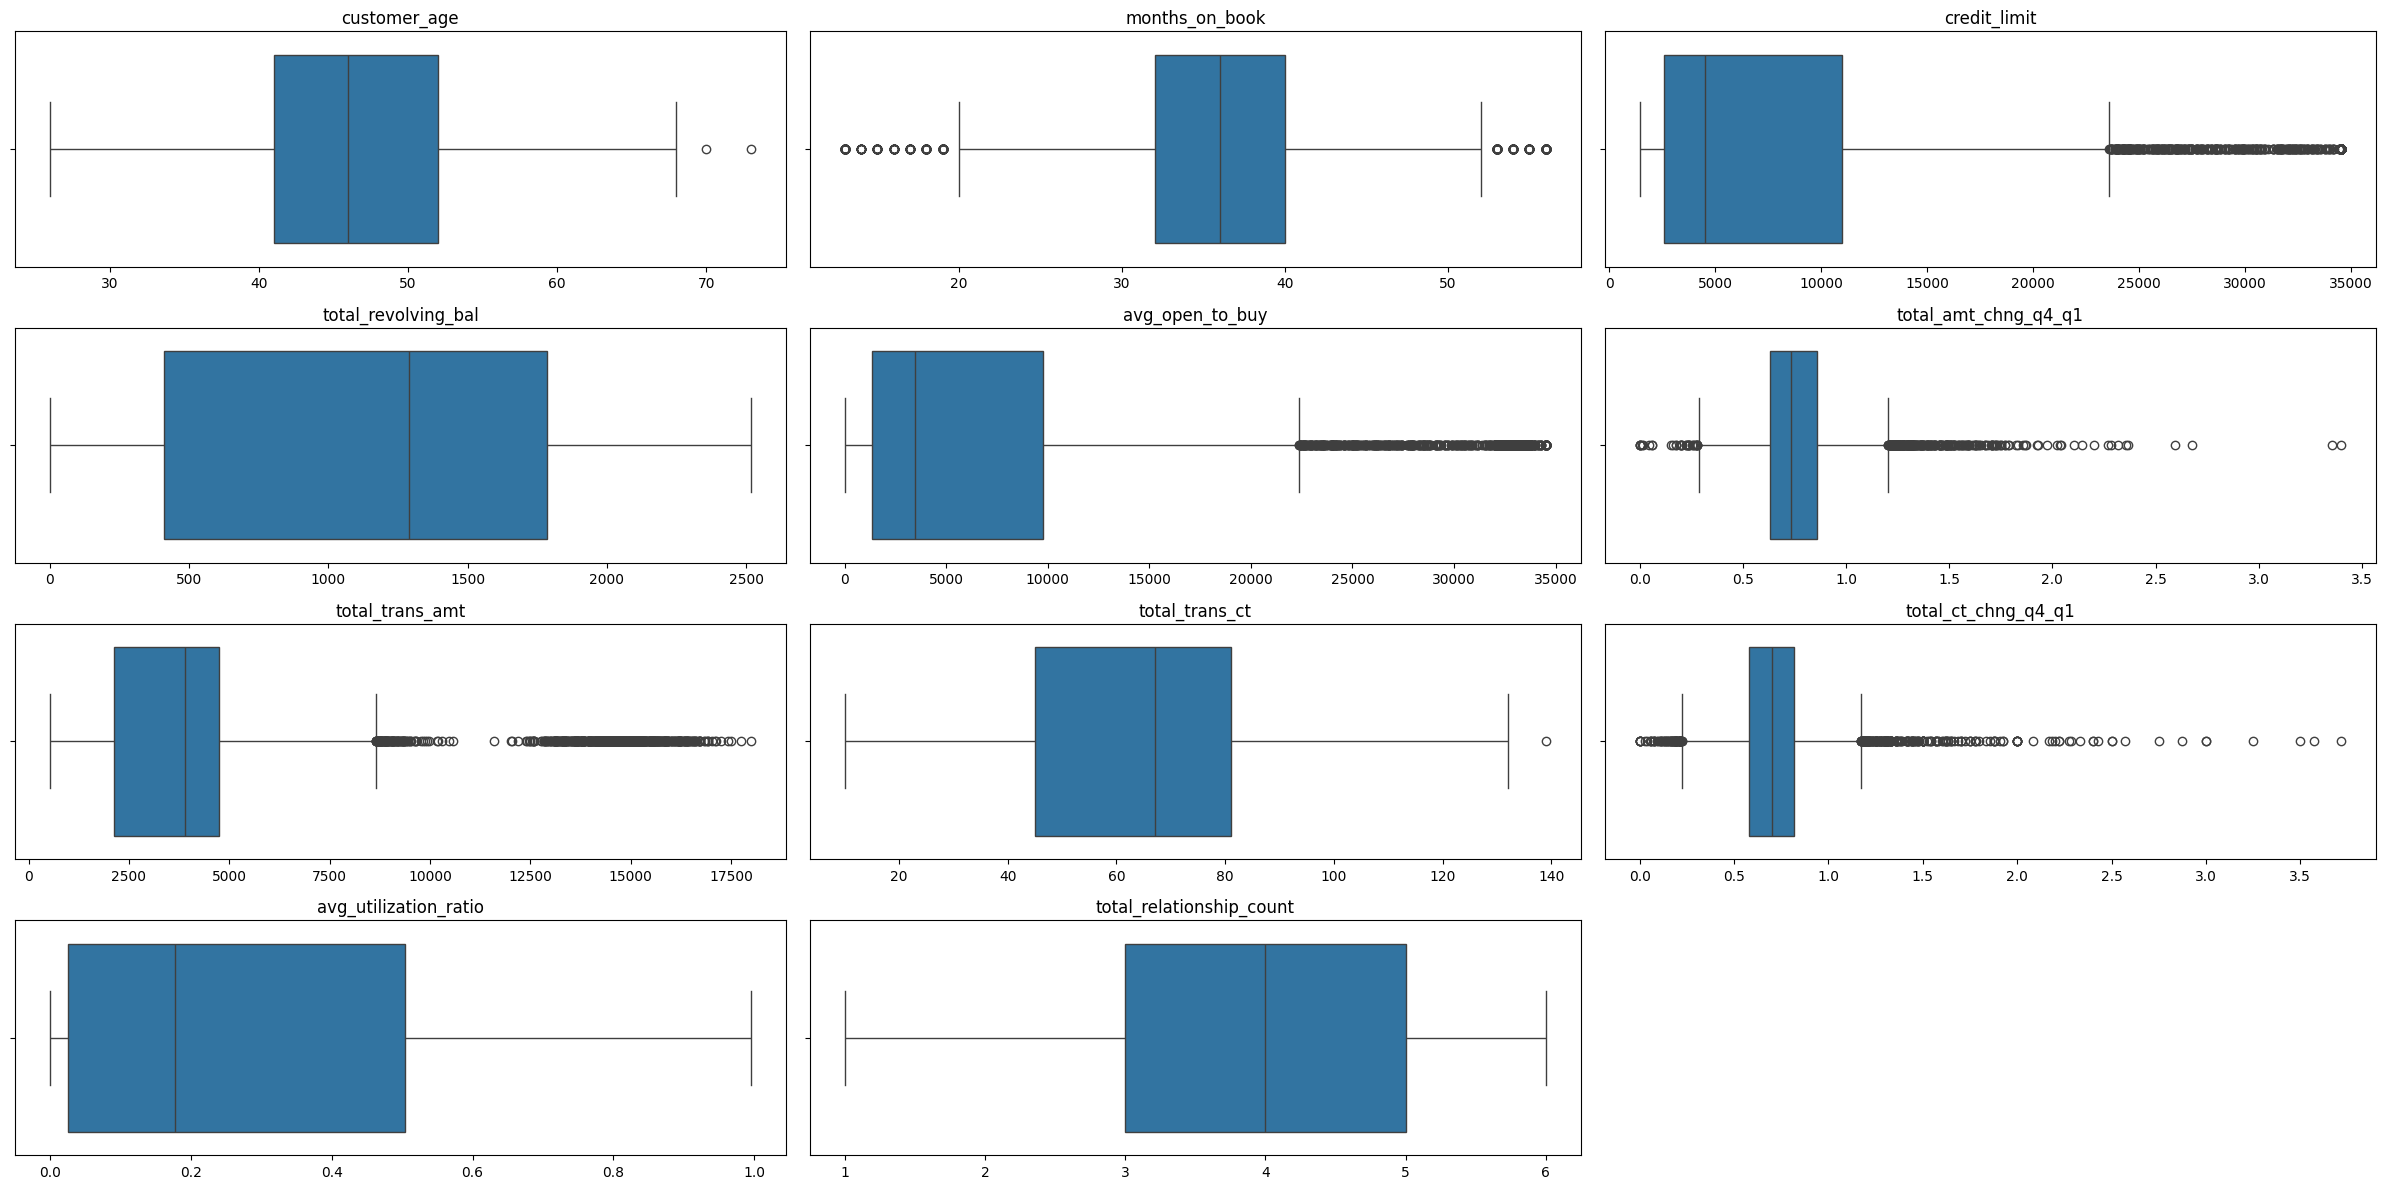

In [24]:
analysis_plots(data=train, features=numplots_features, outliers=True)

As proporções de outliers são baixas em cada feature. Como não parecem representar erros de medição, não os removerei.

### Distribuições das features categóricas
Vou analisar as distribuições para avaliar as características mais comuns dos clientes. Incluirei algumas variáveis discretas nestes gráficos para facilitar a visualização em gráficos de contagem.

In [25]:
barplot_discrete_features = ['gender', 
                             'dependent_count', 
                             'months_inactive_12_mon', 
                             'contacts_count_12_mon']
barplot_features = barplot_discrete_features + categorical_features

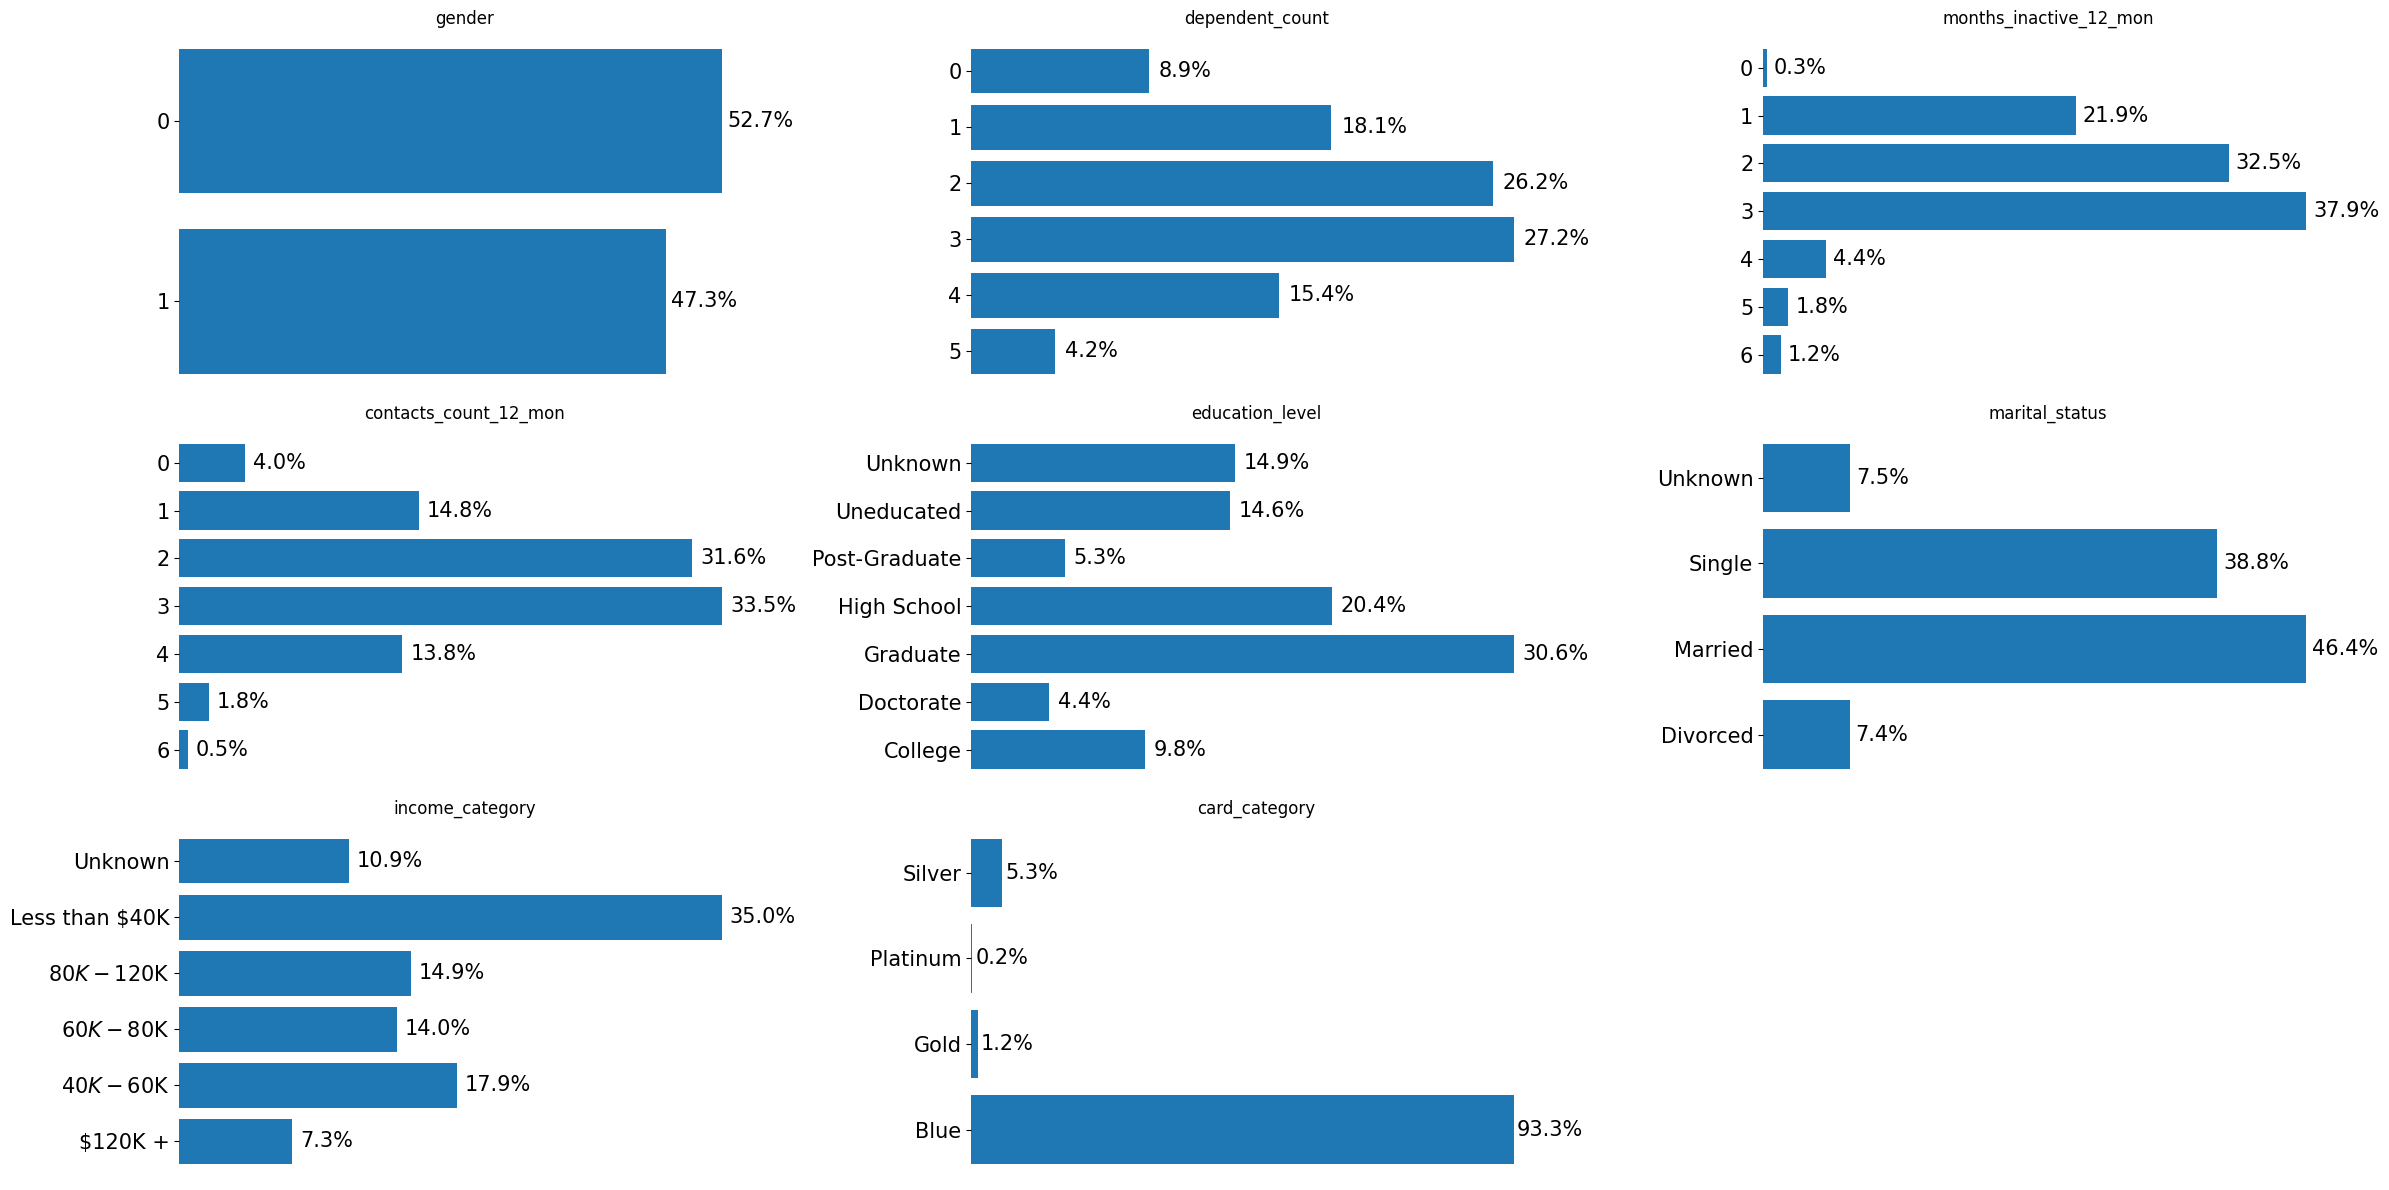

In [26]:
analysis_plots(data=train, features=barplot_features, barplot=True, figsize=(24, 12))

Insights:
- Quase 53% dos clientes são mulheres.
- Mais de 50% dos clientes têm 2 ou 3 dependentes.
- 90% dos clientes ficaram inativos de 1 a 3 meses no último ano.
- A maioria dos clientes (aproximadamente 65%) contatou o banco 2 ou 3 vezes nos últimos 12 meses.
- A maioria dos clientes é casada ou solteira, com ensino superior, ganha menos de $40K e possui um cartão Blue.
- Existem algumas categorias com proporções extremamente baixas, como 0 meses inativos e 6 contatos. Além disso, a categoria de cartão é altamente desbalanceada (93,3% Blue). Isso será considerado na modelagem.

### Análise bivariada e multivariada
Farei análises bivariadas e multivariadas para ver como as features se relacionam umas com as outras, particularmente com a variável alvo (churn_flag).

### Matriz de correlação
Examinarei a matriz de correlação para identificar relações lineares entre as features, particularmente com o alvo, e avaliar a força dessas relações.

In [27]:
corr_matrix = train.corr(numeric_only=True)

In [28]:
corr_matrix['churn_flag'].sort_values(ascending=False)

churn_flag                  1.000000
contacts_count_12_mon       0.205486
months_inactive_12_mon      0.157937
dependent_count             0.030940
customer_age                0.017256
months_on_book              0.008124
avg_open_to_buy             0.000161
credit_limit               -0.023976
gender                     -0.042009
total_amt_chng_q4_q1       -0.129157
total_relationship_count   -0.157092
total_trans_amt            -0.173479
avg_utilization_ratio      -0.188519
total_revolving_bal        -0.267587
total_ct_chng_q4_q1        -0.286473
total_trans_ct             -0.372500
Name: churn_flag, dtype: float64

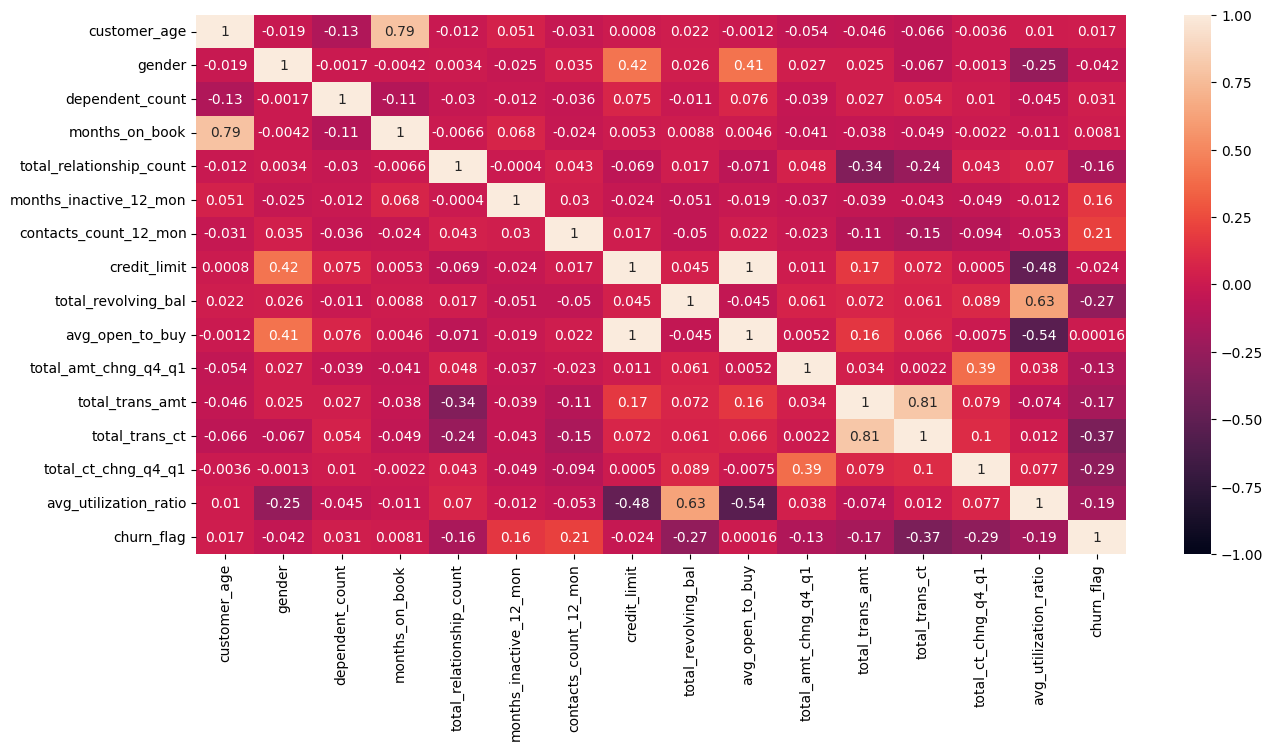

In [29]:
plt.figure(figsize=(15, 7))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True)
plt.show()

Insights:
- A contagem total de transações, saldo rotativo total e mudança na contagem total têm uma correlação negativa moderada com o alvo. Isso faz sentido: menos transações, maior a chance de churn.
- Idade do cliente e meses no banco (months on book) são fortemente correlacionados positivamente. O banco deve focar em reter clientes antigos e aumentar o tempo de retenção dos jovens.
- Limite de crédito e taxa média de utilização são moderadamente negativamente correlacionados. Limite maior = taxa de utilização menor.
- Saldo rotativo total e taxa de utilização média têm forte correlação positiva.
- Curiosamente, gênero tem uma correlação positiva moderada com limite de crédito (homens tendem a ter limites maiores).
- Algumas features como valor e contagem total de transações são altamente correlacionadas. Como focarei em poder preditivo com LightGBM, não me preocuparei muito com multicolinearidade agora.
- Curiosamente, a média disponível para compra e o limite de crédito são perfeitamente correlacionados positivamente. Um deles é redundante. Descartarei avg_open_to_buy na etapa de modelagem.

Vamos ver algumas dessas relações abaixo.

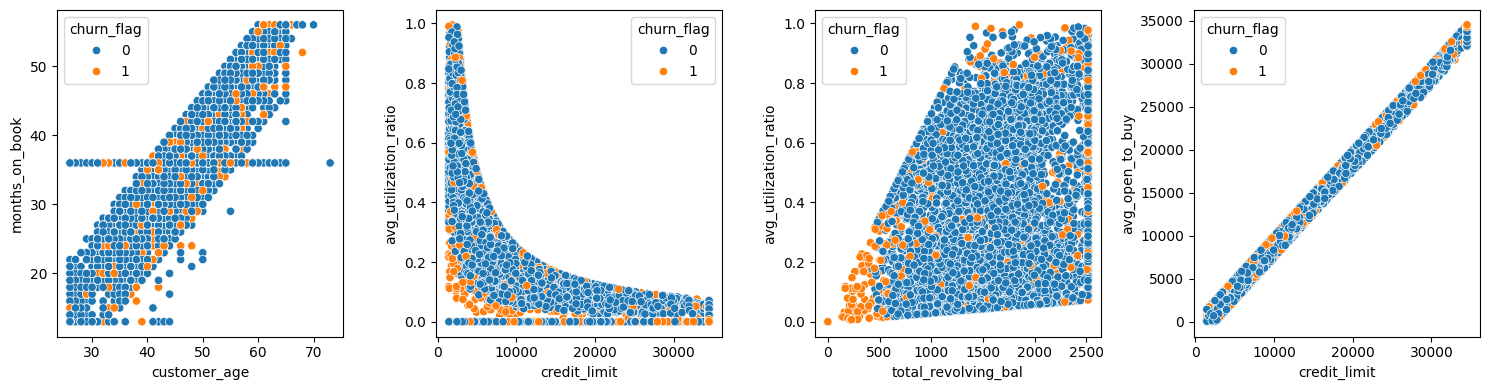

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
sns.scatterplot(data=train, x='customer_age', y='months_on_book', hue='churn_flag', ax=axes[0])
sns.scatterplot(data=train, x='credit_limit', y='avg_utilization_ratio',  hue='churn_flag', ax=axes[1])
sns.scatterplot(data=train, x='total_revolving_bal', y='avg_utilization_ratio',  hue='churn_flag', ax=axes[2])
sns.scatterplot(data=train, x='credit_limit', y='avg_open_to_buy',  hue='churn_flag', ax=axes[3])
plt.tight_layout()
plt.show()

Curiosamente, limite de crédito e taxa de utilização média apresentam uma relação decrescente exponencial! À medida que o limite aumenta, a taxa de utilização cai exponencialmente.

### Distribuições de features numéricas pelo flag de churn
Vou analisar as distribuições de clientes existentes e os que cancelaram para ver se há alguma diferença significativa.

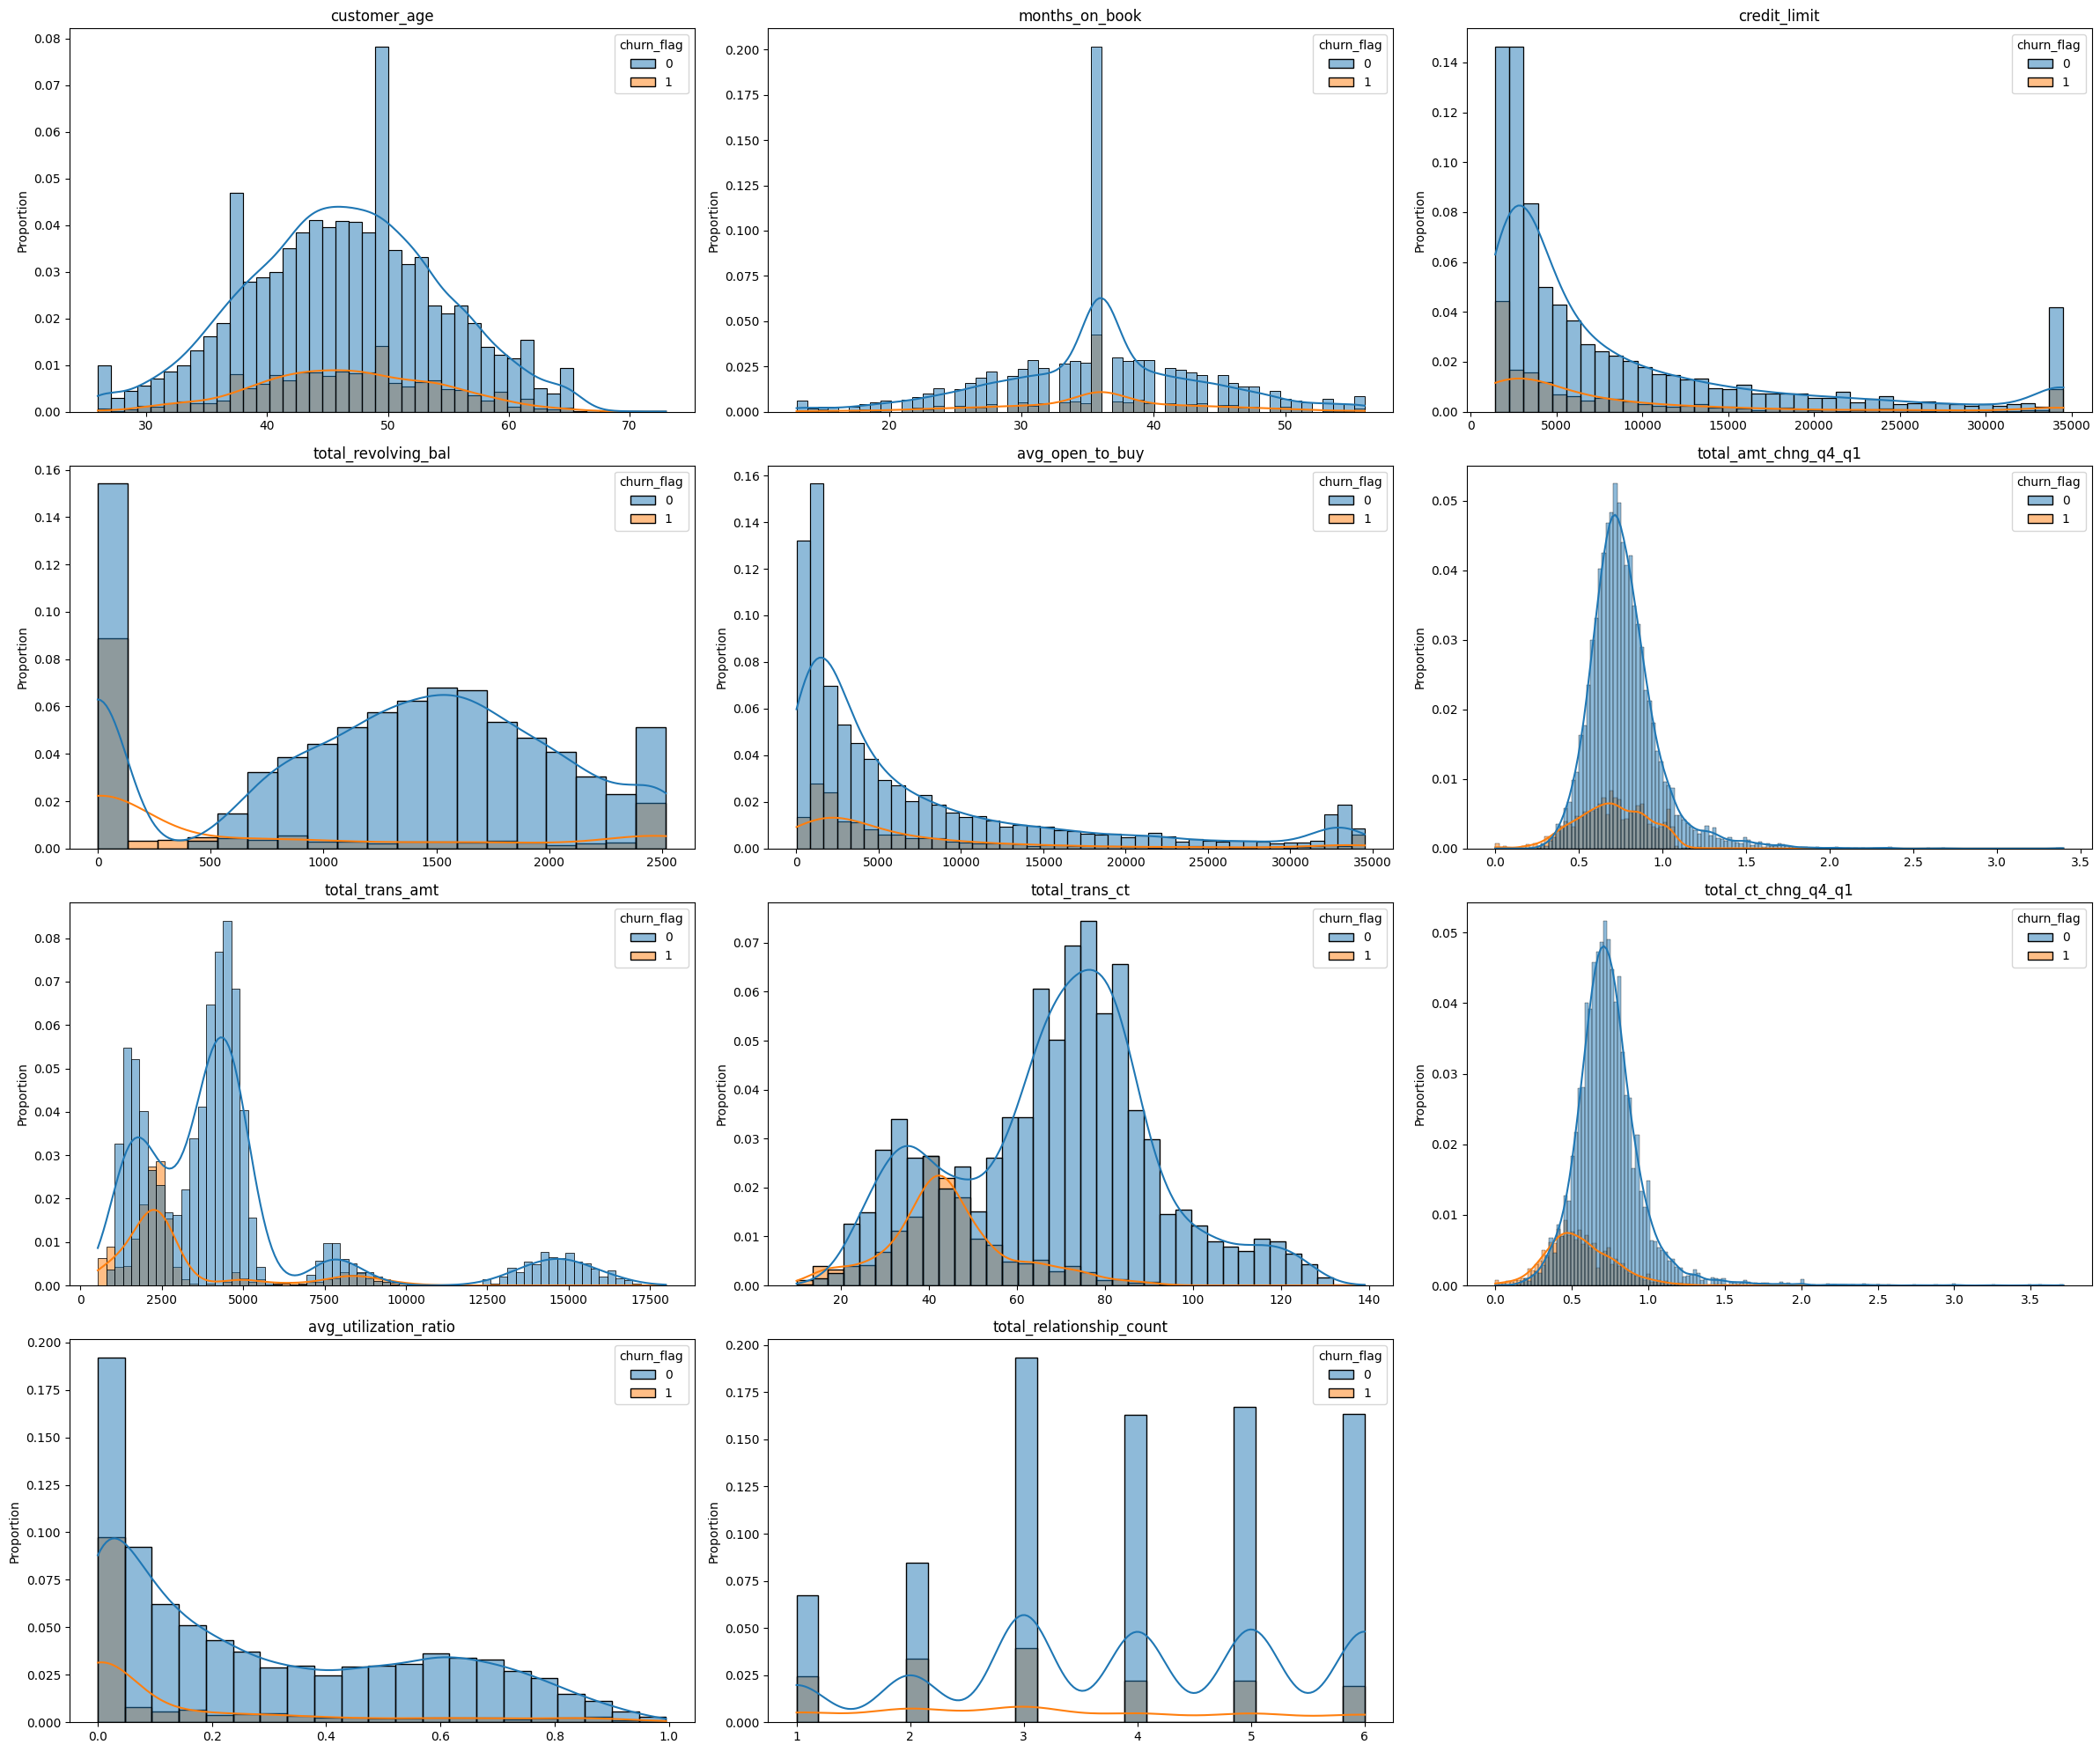

In [31]:
analysis_plots(data=train, features=numplots_features, histplot=True, kde=True, hue=target, figsize=(24, 20))

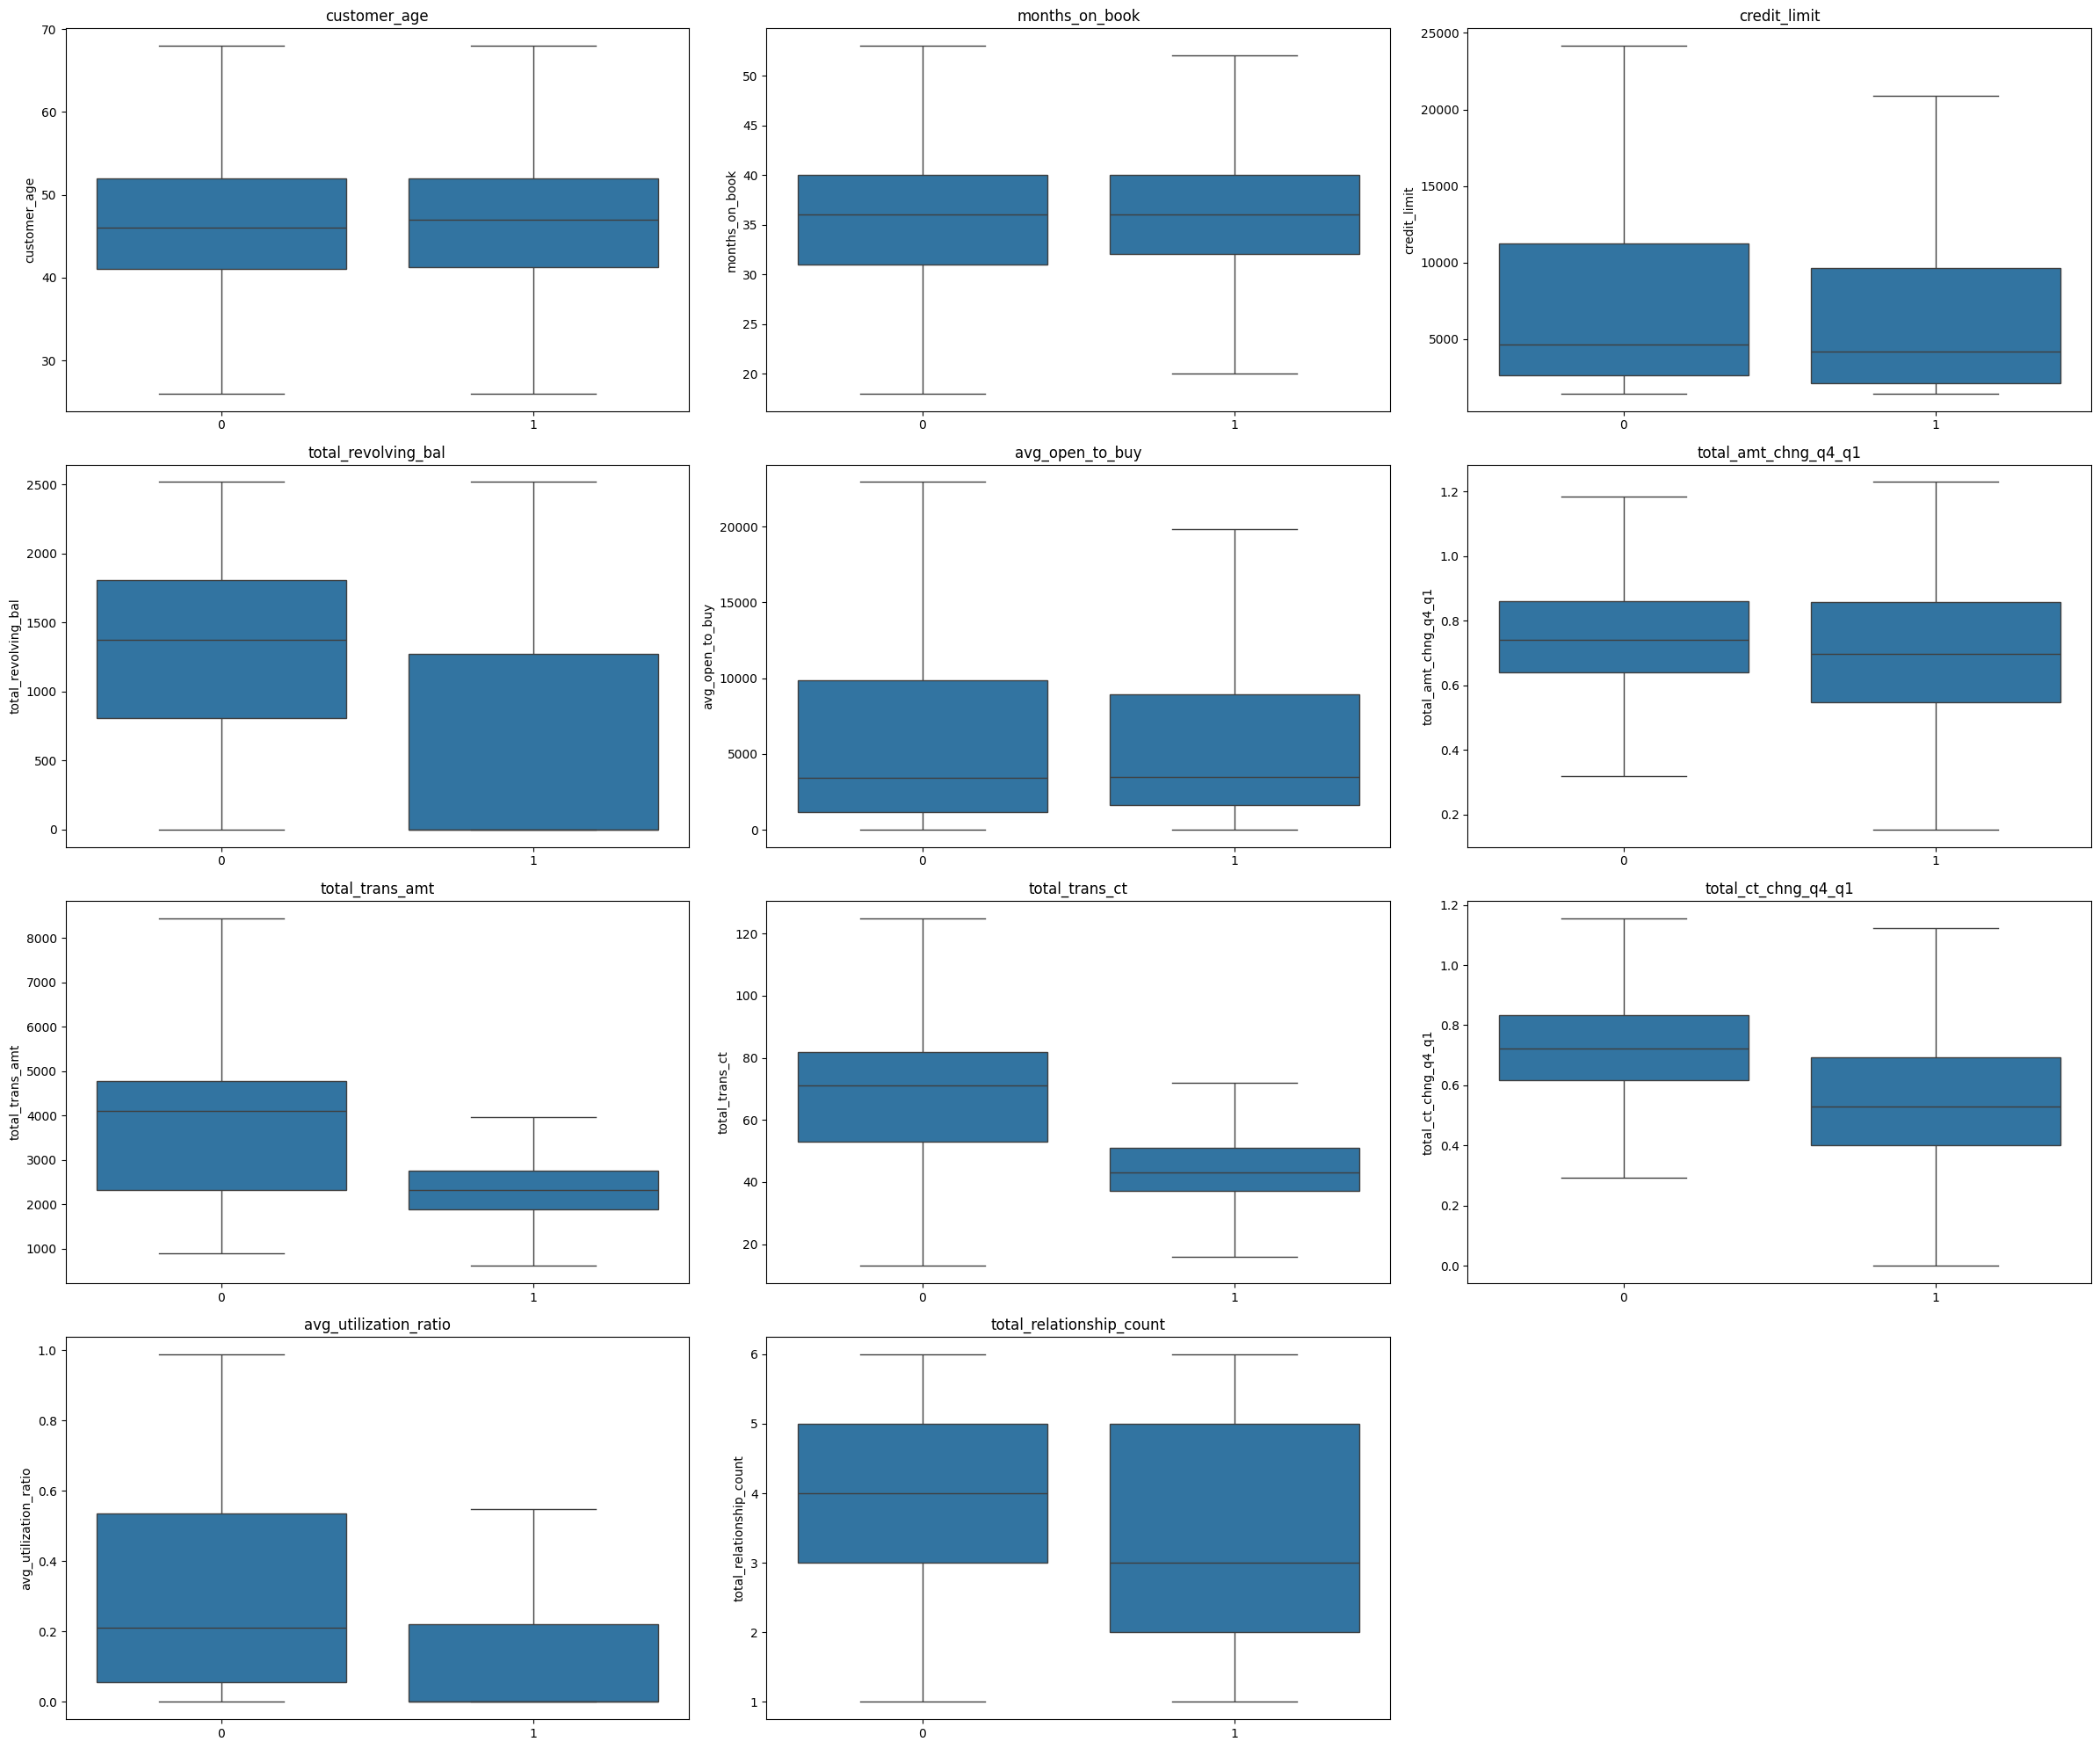

In [32]:
analysis_plots(data=train, features=numplots_features, boxplot=True, boxplot_x=target, figsize=(24, 20))

Insights:
- Clientes que cancelam tendem a ter menos produtos do banco (geralmente entre 1 e 3 produtos).
- Clientes que cancelam tendem a ter limites de crédito ligeiramente menores.
- Clientes que cancelam tendem a ter saldos rotativos menores (muitos com saldo zero), pois usam menos o cartão.
- Clientes que cancelam tendem a ter valores e contagens de transações menores, o que faz total sentido.
- Clientes que cancelam tendem a ter menores mudanças em suas contagens de transações.
- Como esperado, clientes que cancelam tendem a ter uma taxa média de utilização menor, muitos com taxa zero.
- Uma boa prática seria discretizar essas features para melhor análise, mas como focarei em modelos robustos como LightGBM, a discretização aumentaria a dimensionalidade e provavelmente seria prejudicial.

### Distribuições de features categóricas pela taxa de churn
Vou olhar como a taxa de churn está distribuída nas diferentes categorias para avaliar quais têm maiores proporções de churners.

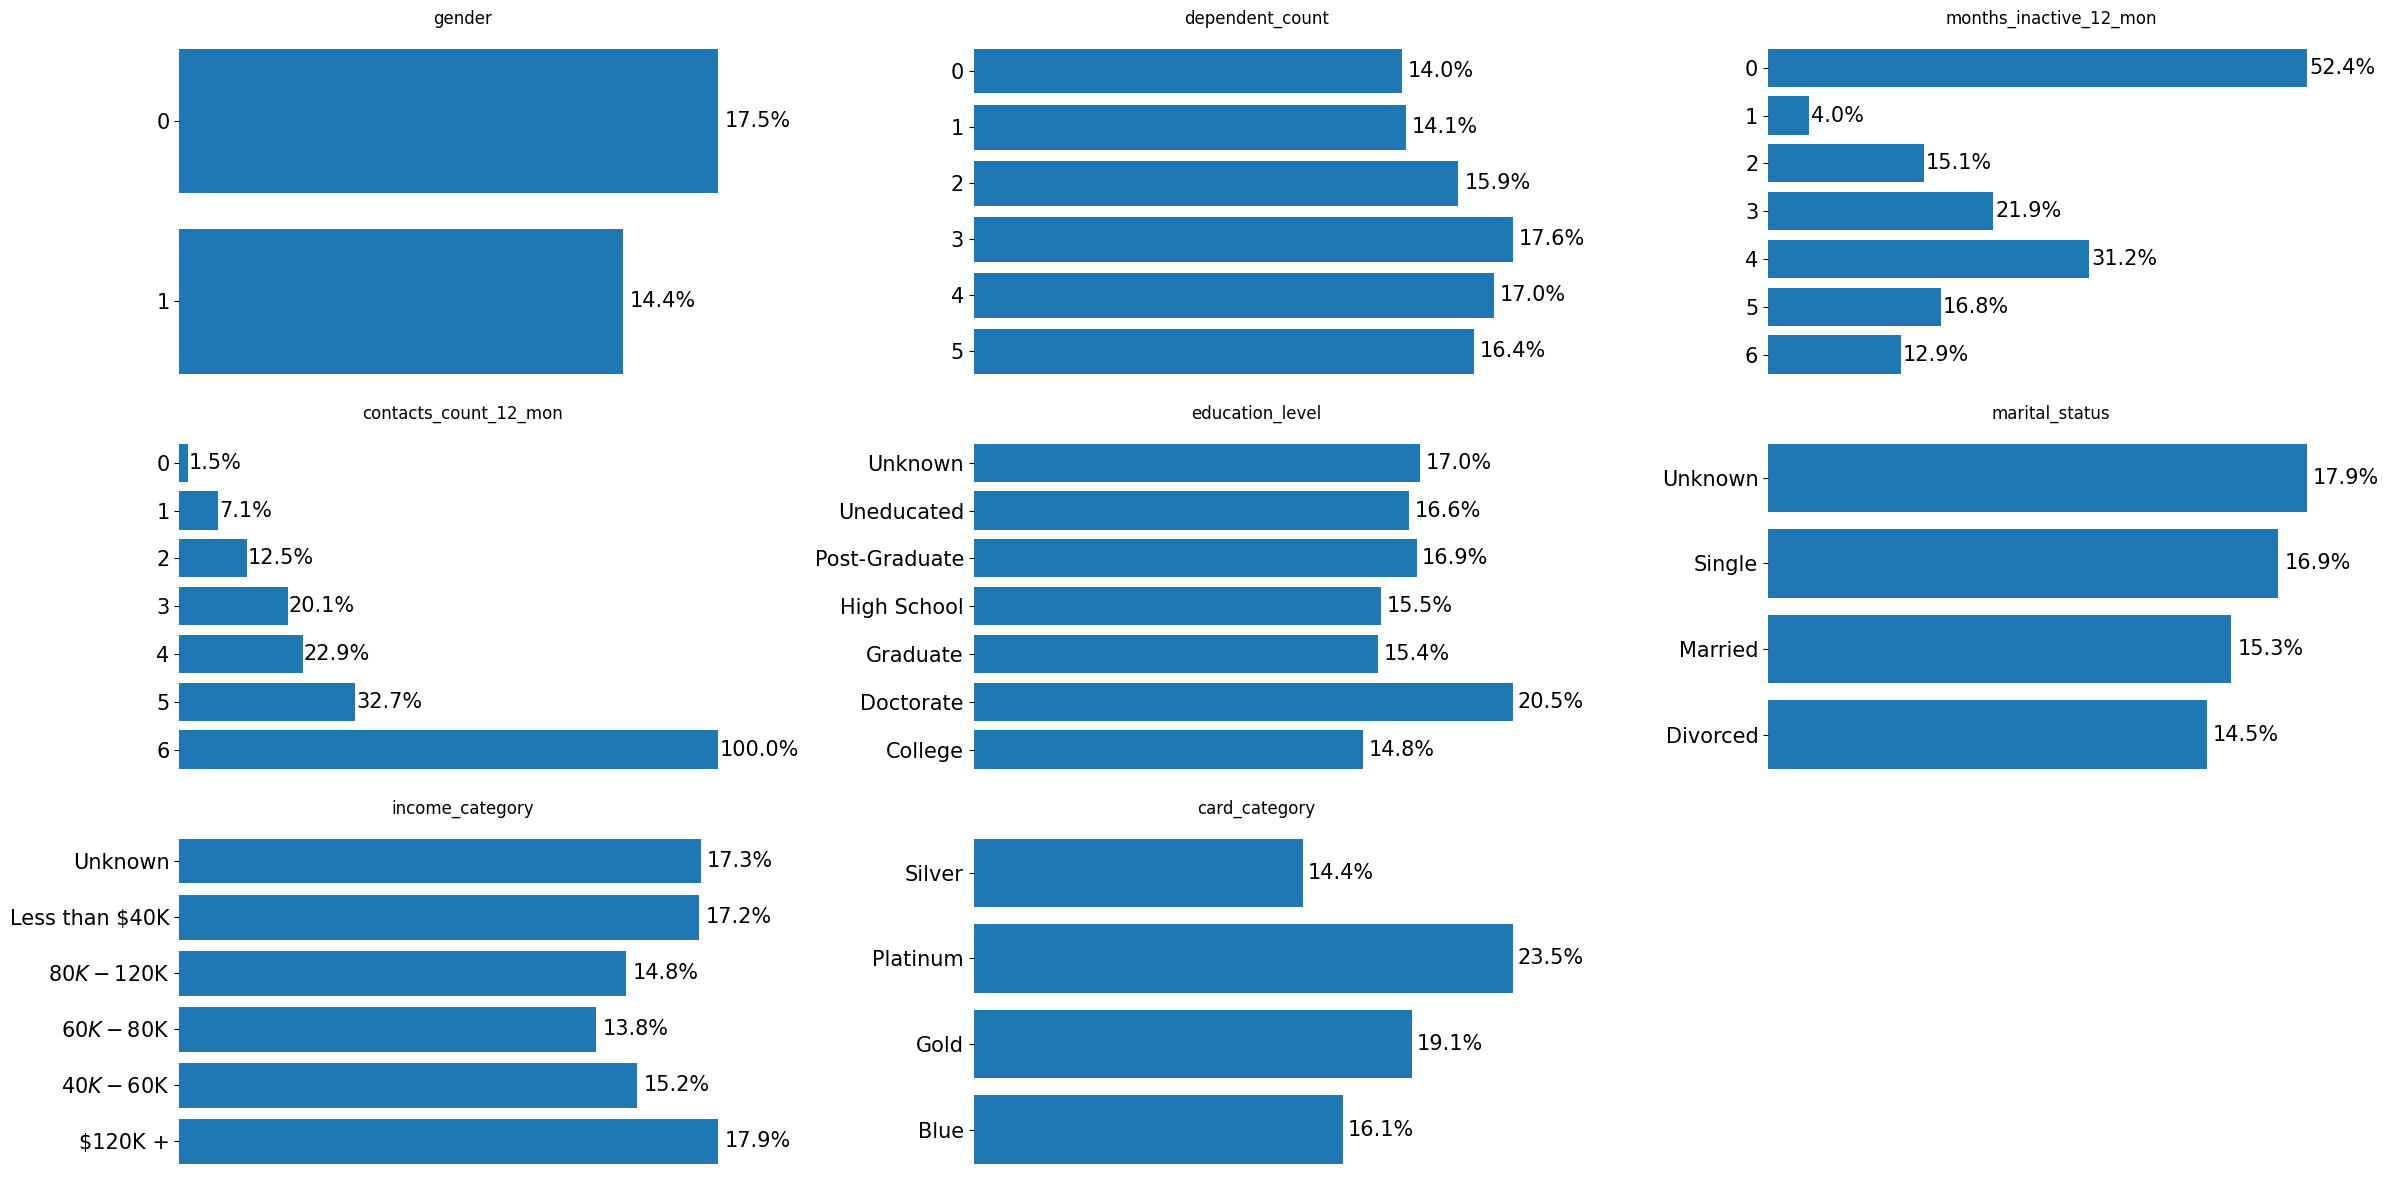

In [33]:
analysis_plots(data=train, features=barplot_features, barplot=True, figsize=(24, 12), hue=target, text_y=0.2)

Insights:
- A taxa de churn aumenta consistentemente à medida que o número de contatos com o banco cresce. Todos que fizeram seis contatos cancelaram.
- No estado civil, a categoria 'desconhecido' apresenta a maior taxa de churn. Para escolaridade e renda, apresenta a segunda maior. É bom deixá-la como uma categoria separada.
- Embora a categoria de cartão seja desbalanceada para Blue, o tipo Platinum apresenta a maior taxa de churn.
- A taxa de churn é maior para mulheres.
- Surpreendentemente, clientes que nunca ficaram inativos nos últimos 12 meses apresentam a maior taxa de churn.
- Clientes com doutorado apresentam a maior taxa de churn em relação aos outros níveis educacionais.

### Conclusões da EDA

<b>Principais insights:</b>
- O banco deve estar alerta à distribuição da taxa de utilização média (cerca de 25% têm taxa zero). Estratégias para aumentar a utilização são necessárias.
- 90% dos clientes ficaram inativos de 1 a 3 meses. Estratégias para evitar inatividade são importantes.
- 75% dos clientes contataram o banco pelo menos 2 vezes. Por que estão ligando? Estão insatisfeitos com o serviço de cartão de crédito?
- Focar na retenção de clientes antigos leais e aumentar a retenção dos mais jovens (idade e tempo de casa são fortemente correlacionados).
- Limite de crédito e taxa média de utilização apresentam uma relação decrescente exponencial.
- Clientes que cancelam tendem a ter menores limites de crédito, saldos rotativos, valores/contagens de transações e taxas de utilização (muitos com taxa zero).
- A taxa de churn aumenta consistentemente à medida que o número de contatos sobe (todos com seis contatos cancelaram). Clientes com doutorado também apresentam a maior taxa de churn.

### Conclusões e Próximos Passos (Feature Engineering e Pré-Processamento)

A Análise Exploratória revelou fortes indicadores de *churn* ligados principalmente ao **comportamento de transações** e à **fricção de atendimento**. Com base nos *insights* obtidos, os próximos passos do projeto envolverão:

1. **Tratamento de Dados Categóricos:** Aplicar `OrdinalEncoder` para variáveis com hierarquia e `OneHotEncoder` para variáveis nominais.
2. **Dimensionamento (Scaling):** Normalizar as variáveis numéricas para garantir o desempenho adequado em modelos sensíveis à escala (ex: Regressão Logística, SVM).
3. **Engenharia de Features:** Explorar interações entre as variáveis, por exemplo, criar *features* de razão entre limite e saldo ou entre inatividade e uso recente.
4. **Modelagem:** Iniciar o processo de *Pipeline* para treinar modelos focados em prever a probabilidade de cancelamento, equilibrando cuidadosamente Precision e Recall.


In [ ]:
# Salvando o Dataset com as alterações feitas
test = pd.concat([X_test, y_test], axis=1)

# Salvando as bases separadamente
train.to_csv('../data/processed/train.csv', index=False, encoding='utf-8')
test.to_csv('../data/processed/test.csv', index=False, encoding='utf-8')